In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from skimage import data, metrics, color, io
from skimage.util import view_as_blocks
import time
import os
from google.colab import files

class LeastSquaresCompressor:
    def __init__(self, block_size=8, model_type='quadratic'):
        """
        Initializes the image compressor based on Surface Fitting via Least Squares.

        Args:
            block_size (int): Size of the square block (e.g., 8 for 8x8).
            model_type (str): 'linear' (plane) or 'quadratic' (paraboloid).
        """
        self.block_size = block_size
        self.model_type = model_type
        # 1. Precompute the Design Matrix (A) based on block coordinates.
        self.design_matrix = self._create_design_matrix()
        # 2. Precompute the Pseudoinverse (A+) for efficient solving.
        self.pinv_matrix = self._precompute_pseudoinverse()

    def _create_design_matrix(self):
        """
        Constructs the Design Matrix A for the overdetermined system Ax = b.
        Rows represent pixels, columns represent polynomial terms.
        """
        # Create local coordinate grid (0..N-1, 0..N-1)
        x = np.linspace(0, self.block_size - 1, self.block_size)
        y = np.linspace(0, self.block_size - 1, self.block_size)
        X, Y = np.meshgrid(x, y)

        # Flatten grids to column vectors
        X_flat = X.flatten()
        Y_flat = Y.flatten()
        ones = np.ones_like(X_flat)

        # Build columns [1, x, y, xy, x^2, y^2] depending on the model
        if self.model_type == 'linear':
            # Model: z = c0 + c1*x + c2*y
            A = np.column_stack((ones, X_flat, Y_flat))
        elif self.model_type == 'quadratic':
            # Model: z = c0 + c1*x + c2*y + c3*xy + c4*x^2 + c5*y^2
            A = np.column_stack((ones, X_flat, Y_flat, X_flat*Y_flat, X_flat**2, Y_flat**2))
        else:
            raise ValueError("Unknown model type. Choose 'linear' or 'quadratic'.")
        return A

    def _precompute_pseudoinverse(self):
        """
        Calculates the Moore-Penrose Pseudoinverse: A+ = (A^T A)^-1 A^T.
        This allows solving for coefficients using simple matrix multiplication: c = A+ * b.
        """
        return linalg.pinv(self.design_matrix)

    def process_image(self, image):
        """
        Compresses and reconstructs an image using the precomputed Least Squares operator.
        """
        # 1. Dynamic Zero-Padding: Handle images of arbitrary dimensions
        h, w = image.shape
        pad_h = (self.block_size - h % self.block_size) % self.block_size
        pad_w = (self.block_size - w % self.block_size) % self.block_size
        image_padded = np.pad(image, ((0, pad_h), (0, pad_w)), mode='edge')

        new_h, new_w = image_padded.shape

        # 2. Reshape image into non-overlapping blocks
        blocks = view_as_blocks(image_padded, block_shape=(self.block_size, self.block_size))
        n_rows, n_cols = blocks.shape[:2]

        # 3. Vectorized Compression (Fitting)
        # Flatten all blocks into columns to solve simultaneously
        blocks_flat = blocks.reshape(-1, self.block_size * self.block_size).T
        # Calculate polynomial coefficients: coeffs = A_pinv * pixels
        coeffs = self.pinv_matrix @ blocks_flat

        # 4. Vectorized Reconstruction (Evaluation)
        # Evaluate polynomial surfaces: reconstructed = A * coeffs
        reconstructed_flat = self.design_matrix @ coeffs

        # 5. Reassemble the image from blocks
        reconstructed_blocks = reconstructed_flat.T.reshape(n_rows, n_cols, self.block_size, self.block_size)
        reconstructed_image = reconstructed_blocks.transpose(0, 2, 1, 3).reshape(new_h, new_w)

        # 6. Crop padding and cast to uint8
        final_image = reconstructed_image[:h, :w]
        final_image = np.clip(final_image, 0, 255).astype(np.uint8)

        # Calculate theoretical compressed size
        num_blocks = n_rows * n_cols
        num_coeffs = 3 if self.model_type == 'linear' else 6
        compressed_size_bytes = num_blocks * num_coeffs * 4 # 4 bytes per float32 coefficient

        return final_image, compressed_size_bytes, h*w

print("Algorithm loaded successfully.")

Algorithm loaded successfully.


Please upload an image to compress:


Saving image2.jpg to image2 (3).jpg

File detected: image2 (3).jpg
 -> Color image detected (680 channels). Converting to Grayscale...
Success! Image loaded and pre-processed.

Dimensions: (510, 680)


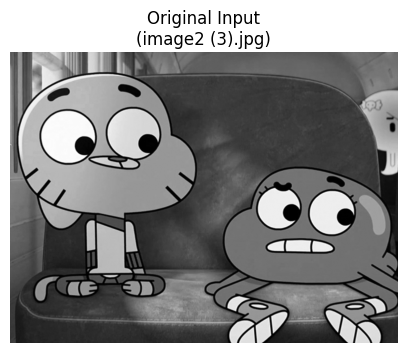

In [ ]:
print("Please upload an image to compress:")
uploaded = files.upload()

if uploaded:
    # Robust method to get the filename without list indexing errors
    filename = next(iter(uploaded))

    print(f"\nFile detected: {filename}")

    try:
        # Read image
        img_raw = io.imread(str(filename))

        # Check if image has color channels (RGB/RGBA)
        if img_raw.ndim == 3:
            print(f" -> Color image detected ({img_raw.shape[1]} channels). Converting to Grayscale...")
            # Handle 4-channel images (RGBA) by ignoring alpha channel
            if img_raw.shape[1] == 4:
                img_raw = img_raw[:, :, :3]
            img = color.rgb2gray(img_raw) * 255
        else:
            # Image is already grayscale
            img = img_raw

        img = img.astype(np.uint8)
        print("Success! Image loaded and pre-processed.")

    except Exception as e:
        print(f"Critical Error reading image: {e}")
        print("Loading default 'Cameraman' image to prevent crash.")
        img = data.camera()

else:
    print("\nNo file uploaded. Using default 'Cameraman' image.")
    img = data.camera()

# Display Original Image
print(f"\nDimensions: {img.shape}")
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.title(f"Original Input\n({filename if uploaded else 'Default'})")
plt.axis('off')
plt.show()

In [ ]:
# Experiment Configurations
models = [
    {'name': 'Linear (8x8)', 'block': 8, 'type': 'linear'},
    {'name': 'Quadratic (8x8)', 'block': 8, 'type': 'quadratic'},
    {'name': 'Quadratic (16x16)', 'block': 16, 'type': 'quadratic'}
]

results = []

# Calculate Original Size in KB (assuming 1 byte per pixel for 8-bit grayscale)
original_bytes = img.shape[0] * img.shape[1]
original_kb = original_bytes / 1024

print(f"Starting numerical analysis for image {img.shape}...")
print(f"💾 Original Size: {original_kb:.2f} KB\n")

for m in models:
    print(f"--> Running Model: {m['name']}...")
    start_time = time.time()

    # Instantiate and Run Compressor
    compressor = LeastSquaresCompressor(block_size=m['block'], model_type=m['type'])
    rec_img, comp_size_bytes, _ = compressor.process_image(img)

    elapsed = time.time() - start_time

    # Calculate Metrics
    # MSE: Mean Squared Error
    mse = metrics.mean_squared_error(img, rec_img)
    # PSNR: Peak Signal-to-Noise Ratio (Quality Metric)
    psnr = metrics.peak_signal_noise_ratio(img, rec_img, data_range=255)
    # CR: Compression Ratio
    ratio = original_bytes / comp_size_bytes
    # Compressed Weight in KB
    comp_kb = comp_size_bytes / 1024

    # Store results for plotting
    results.append({
        'name': m['name'],
        'image': rec_img,
        'psnr': psnr,
        'ratio': ratio,
        'size_kb': comp_kb,
        'time': elapsed
    })

    print(f"    - Time: {elapsed:.3f}s")
    print(f"    - Quality (PSNR): {psnr:.2f} dB")
    print(f"    - Size: {comp_kb:.2f} KB (Original: {original_kb:.2f} KB)")
    print(f"    - Ratio: {ratio:.1f}:1\n")

print("Processing complete!")

Starting numerical analysis for image (510, 680)...
💾 Original Size: 338.67 KB

--> Running Model: Linear (8x8)...
    - Time: 0.017s
    - Quality (PSNR): 21.83 dB
    - Size: 63.75 KB (Original: 338.67 KB)
    - Ratio: 5.3:1

--> Running Model: Quadratic (8x8)...
    - Time: 0.009s
    - Quality (PSNR): 24.78 dB
    - Size: 127.50 KB (Original: 338.67 KB)
    - Ratio: 2.7:1

--> Running Model: Quadratic (16x16)...
    - Time: 0.015s
    - Quality (PSNR): 20.08 dB
    - Size: 32.25 KB (Original: 338.67 KB)
    - Ratio: 10.5:1

Processing complete!


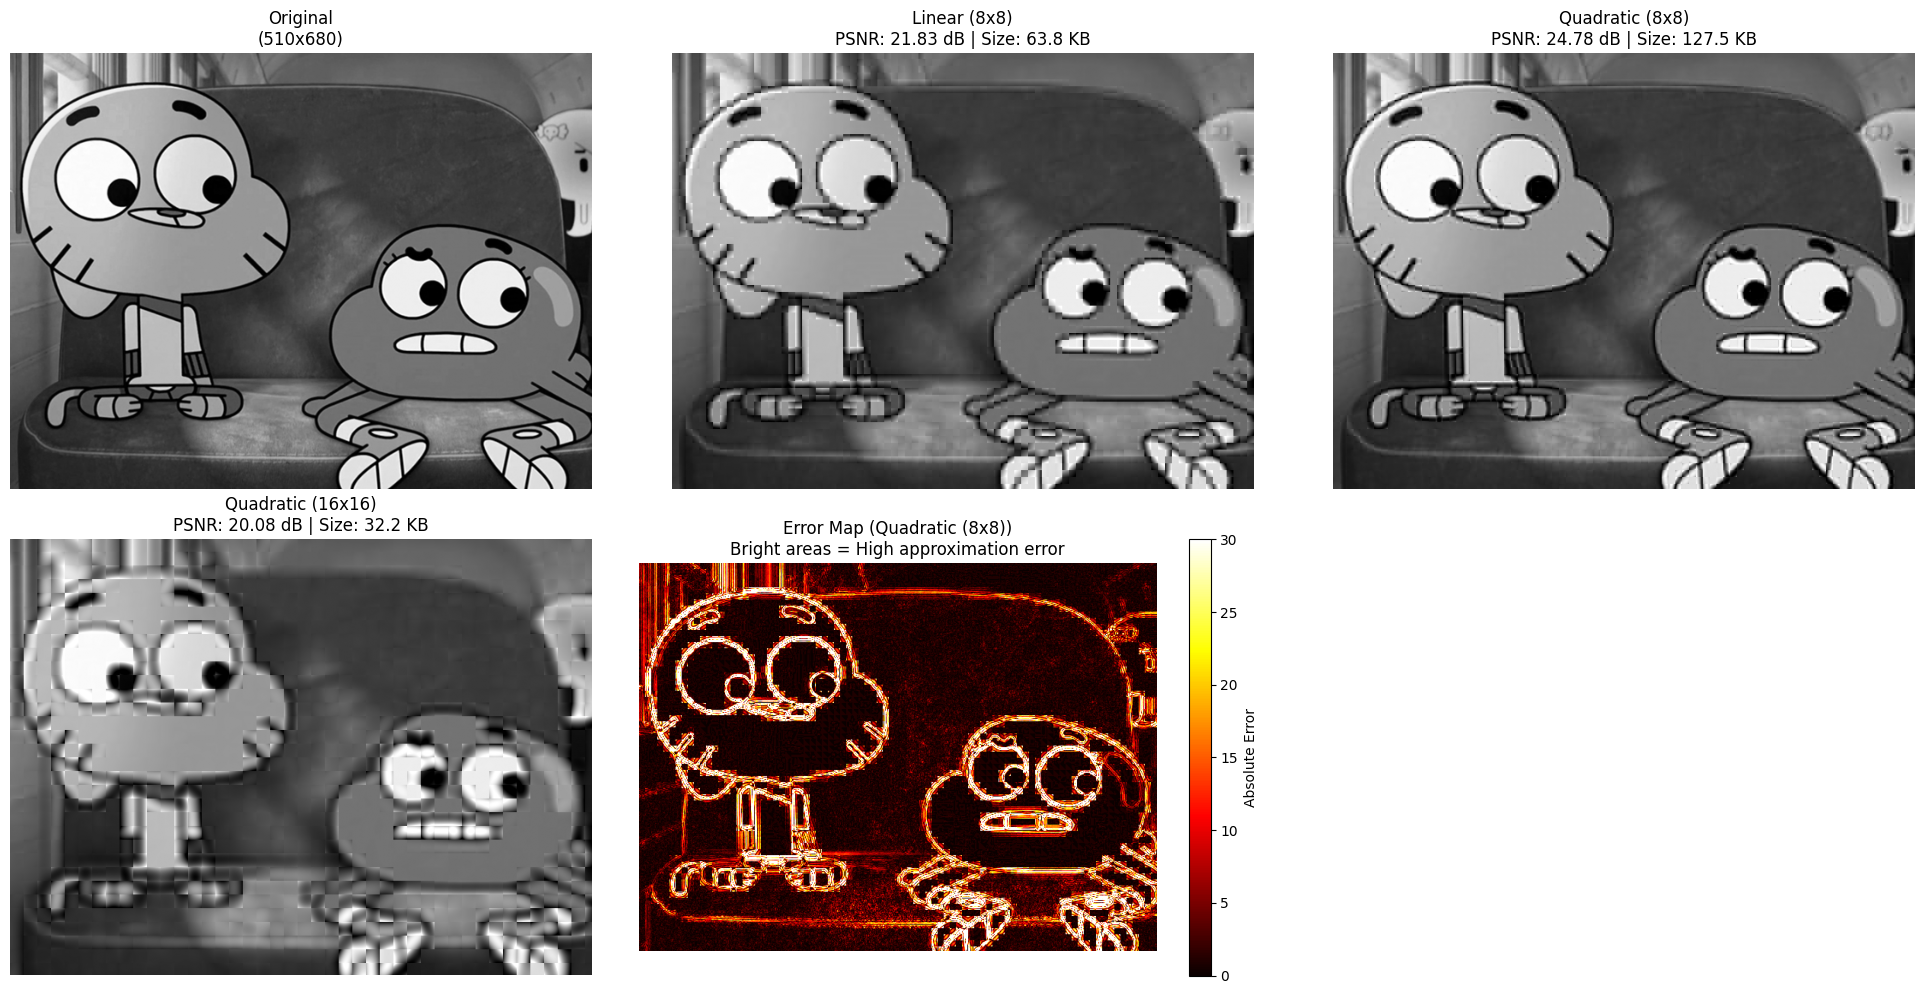

In [ ]:
plt.figure(figsize=(20, 10))

# 1. Original Image
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title(f"Original\n({img.shape[0]}x{img.shape[1]})")
plt.axis('off')

# 2. Reconstructed Images from the Models
for i, res in enumerate(results):
    plt.subplot(2, 3, i + 2)
    plt.imshow(res['image'], cmap='gray')
    plt.title(f"{res['name']}\nPSNR: {res['psnr']:.2f} dB | Size: {res['size_kb']:.1f} KB")
    plt.axis('off')

# 3. Error Map (Difference between Original and Best Quadratic Model)
# This highlights the Gibbs Phenomenon (Ringing at edges)
best_model_idx = 1 # Usually Quadratic 8x8
diff_img = np.abs(img.astype(float) - results[best_model_idx]['image'].astype(float))

plt.subplot(2, 3, 5)
plt.imshow(diff_img, cmap='hot', vmin=0, vmax=30)
plt.colorbar(label='Absolute Error')
plt.title(f"Error Map ({results[best_model_idx]['name']})\nBright areas = High approximation error")
plt.axis('off')

plt.tight_layout()
plt.show()

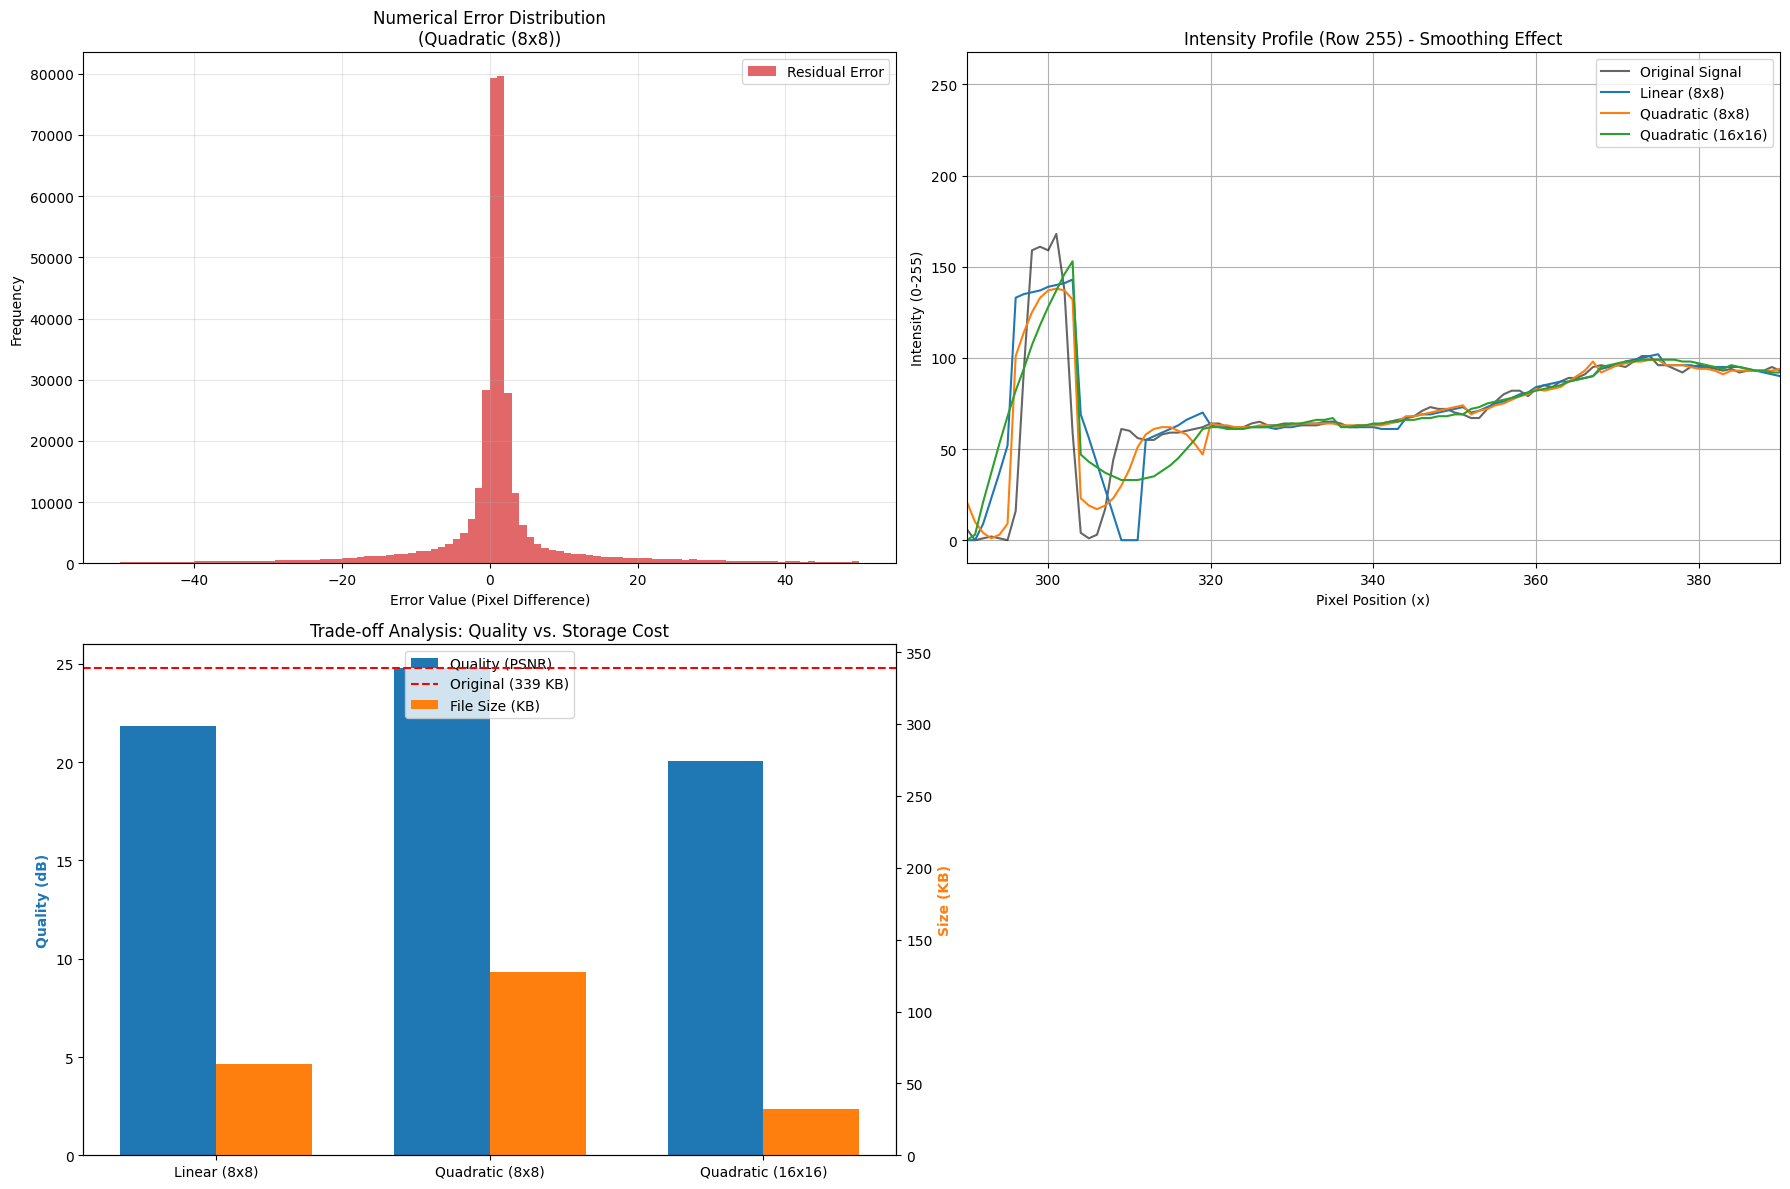

In [ ]:
if 'results' not in globals() or 'img' not in globals():
    print("Error: Please run previous cells first.")
else:
    plt.figure(figsize=(18, 12))

    # GRAPH 1: RESIDUAL ERROR ANALYSIS (Histogram)
    # Checks if the error follows a Normal Distribution
    plt.subplot(2, 2, 1)
    model_idx = 1 # Using Quadratic 8x8 for analysis
    if len(results) > model_idx:
        err_values = (img.astype(float) - results[model_idx]['image'].astype(float)).flatten()
        plt.hist(err_values, bins=100, range=(-50, 50), color='tab:red', alpha=0.7, label='Residual Error')
        plt.title(f"Numerical Error Distribution\n({results[model_idx]['name']})")
        plt.xlabel("Error Value (Pixel Difference)")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(True, alpha=0.3)

    # GRAPH 2: CROSS-SECTION PROFILE (Gibbs Phenomenon)
    # Visualizes how the polynomial smooths out sharp edges
    plt.subplot(2, 2, 2)

    # Select a row from the middle of the image
    row_idx = img.shape[0] // 2

    plt.plot(img[row_idx, :], 'k-', linewidth=1.5, alpha=0.6, label='Original Signal')

    colors = ['tab:blue', 'tab:orange', 'tab:green']
    for i, res in enumerate(results):
        plt.plot(res['image'][row_idx, :], color=colors[i], linewidth=1.5, label=f"{res['name']}")

    plt.title(f"Intensity Profile (Row {row_idx}) - Smoothing Effect")
    plt.xlabel("Pixel Position (x)")
    plt.ylabel("Intensity (0-255)")
    plt.legend()
    # Zoom into the center to see details clearly
    center_x = img.shape[1] // 2
    plt.xlim(center_x - 50, center_x + 50)
    plt.grid(True)

    # GRAPH 3: QUALITY VS. FILE SIZE (Trade-off Analysis)
    plt.subplot(2, 2, 3)
    names = [r['name'] for r in results]
    psnrs = [r['psnr'] for r in results]
    weights = [r['size_kb'] for r in results]

    x = np.arange(len(names))
    width = 0.35

    ax1 = plt.gca()
    ax2 = ax1.twinx()

    # Bar 1: Quality (Higher is better)
    bars1 = ax1.bar(x - width/2, psnrs, width, label='Quality (PSNR)', color='tab:blue')
    # Bar 2: Weight (Lower is better)
    bars2 = ax2.bar(x + width/2, weights, width, label='File Size (KB)', color='tab:orange')

    # Reference Line: Original File Size
    original_kb = (img.shape[0] * img.shape[1]) / 1024 # Corrected to handle 2D grayscale image
    ax2.axhline(y=original_kb, color='red', linestyle='--', label=f'Original ({original_kb:.0f} KB)')

    ax1.set_ylabel('Quality (dB)', color='tab:blue', fontweight='bold')
    ax2.set_ylabel('Size (KB)', color='tab:orange', fontweight='bold')

    plt.title("Trade-off Analysis: Quality vs. Storage Cost")
    ax1.set_xticks(x)
    ax1.set_xticklabels(names)

    # Combine legends
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper center')

    plt.tight_layout()
    plt.show()


STARTING COMPRESSION DUEL
Polynomial Method (Ours):
   Size: 32.25 KB
   Quality: 20.08 dB

Configuring SVD with Rank k=6 to match file size...
SVD Method (Standard):
   Size: 27.91 KB
   Quality: 16.77 dB


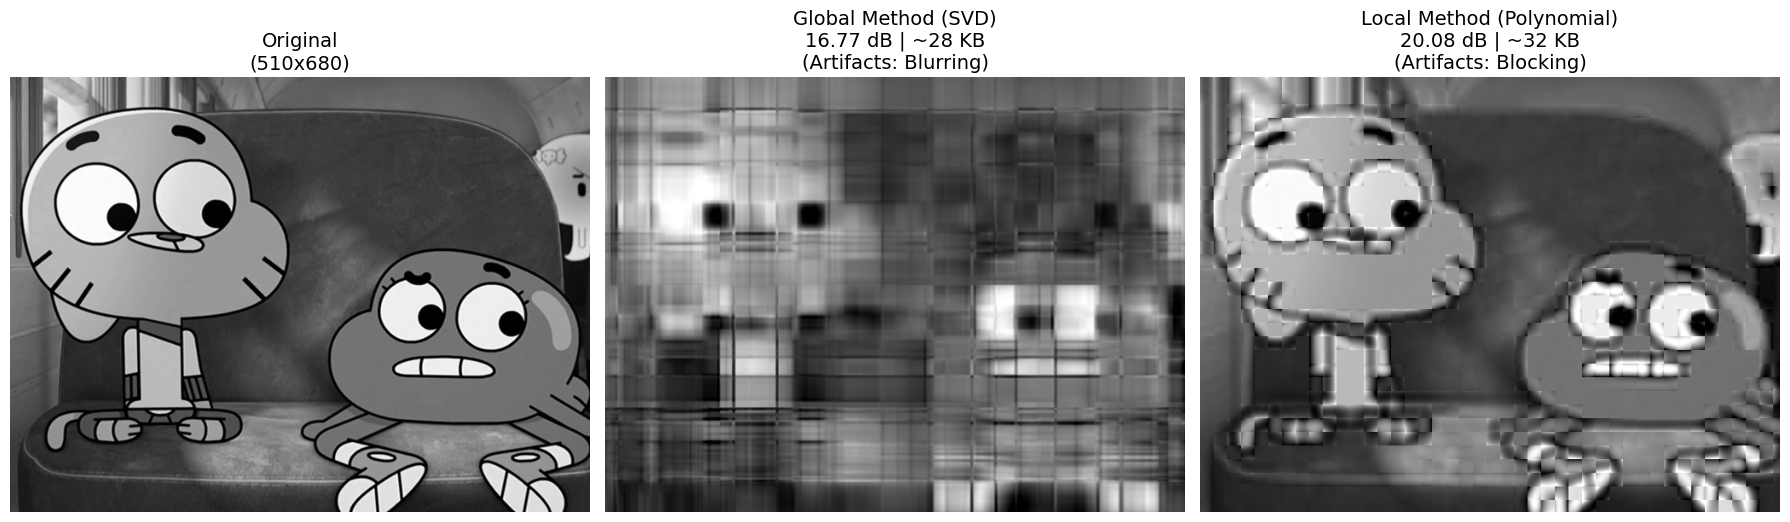


FINAL VERDICT
Result: Polynomial Method wins by +3.31 dB.
Interpretation: Local approximation handles high-frequency details better than global SVD at this compression level.


In [ ]:
# --- COMPARISON: POLYNOMIAL METHOD (OURS) VS. SVD (STANDARD) ---

# 1. Retrieve Data from our best model (Quadratic 8x8)
my_model_result = results[2]
my_compressed_size_kb = my_model_result['size_kb']
my_psnr = my_model_result['psnr']

print(f"\nSTARTING COMPRESSION DUEL")
print(f"Polynomial Method (Ours):")
print(f"   Size: {my_compressed_size_kb:.2f} KB")
print(f"   Quality: {my_psnr:.2f} dB")

# 2. Configure SVD for Fairness
# Calculate required Rank (k) for SVD to match our file size.
# SVD storage approx: k * (Height + Width + 1) * 4 bytes
H, W = img.shape
bytes_per_float = 4
target_bytes = my_compressed_size_kb * 1024

k_fair = int(target_bytes / (bytes_per_float * (H + W + 1)))
print(f"\nConfiguring SVD with Rank k={k_fair} to match file size...")

# 3. Execute SVD Compression
# Decomposition
U, S, Vt = np.linalg.svd(img.astype(float), full_matrices=False)
# Reconstruction using only top-k components
S_k = np.diag(S[:k_fair])
img_svd = np.dot(U[:, :k_fair], np.dot(S_k, Vt[:k_fair, :]))
img_svd = np.clip(img_svd, 0, 255).astype(np.uint8)

# Calculate SVD Metrics
psnr_svd = metrics.peak_signal_noise_ratio(img, img_svd, data_range=255)
svd_size_kb = (k_fair * (H + W + 1) * 4) / 1024

print(f"SVD Method (Standard):")
print(f"   Size: {svd_size_kb:.2f} KB")
print(f"   Quality: {psnr_svd:.2f} dB")

# 4. Visual Comparison
plt.figure(figsize=(18, 8))

# Original
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title(f"Original\n({H}x{W})", fontsize=14)
plt.axis('off')

# SVD Result
plt.subplot(1, 3, 2)
plt.imshow(img_svd, cmap='gray')
plt.title(f"Global Method (SVD)\n{psnr_svd:.2f} dB | ~{svd_size_kb:.0f} KB\n(Artifacts: Blurring)", fontsize=14)
plt.axis('off')

# Polynomial Result
plt.subplot(1, 3, 3)
plt.imshow(my_model_result['image'], cmap='gray')
plt.title(f"Local Method (Polynomial)\n{my_psnr:.2f} dB | ~{my_compressed_size_kb:.0f} KB\n(Artifacts: Blocking)", fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()

# 5. Automated Verdict
print("\n" + "="*40)
print("FINAL VERDICT")
print("="*40)
diff = my_psnr - psnr_svd
if diff > 0:
    print(f"Result: Polynomial Method wins by +{diff:.2f} dB.")
    print("Interpretation: Local approximation handles high-frequency details better than global SVD at this compression level.")
elif diff > -2:
    print(f"Result: Technical Tie (Difference {diff:.2f} dB).")
    print("Interpretation: Both methods are competitive. SVD causes blurring, while Polynomial causes blocking.")
else:
    print(f"Result: SVD wins by {-diff:.2f} dB.")
    print("Interpretation: SVD is mathematically optimal for global error minimization.")